In [108]:
import sys
# Add the root folder where your notebook and mcp_client.py are located
sys.path.append("D:/Uni Stuff/Internships/AiGENThix/jonathan/python-notebook-mcp")

from server import initialize_workspace

In [109]:
initialize_workspace(directory="D:/Uni Stuff/Internships/AiGENThix/jonathan/")

Workspace initialized at: D:/Uni Stuff/Internships/AiGENThix/jonathan/


'Workspace initialized at: D:/Uni Stuff/Internships/AiGENThix/jonathan/\nNotebooks found:\n- integrated-timeline.ipynb\n- integrated.ipynb\n- rule-mining.ipynb'

In [110]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.dates import DateFormatter, AutoDateLocator
from matplotlib import lines as mlines
import seaborn as sns
from datetime import datetime, timedelta
import warnings
warnings.filterwarnings('ignore')

from mlxtend.preprocessing import TransactionEncoder
from mlxtend.frequent_patterns import apriori, association_rules
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from scipy.spatial.distance import cosine

pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 190)
plt.style.use('seaborn-v0_8-darkgrid')

In [111]:
# Load data
df = pd.read_excel('cleaned_data.xlsx')

# Convert date column
df['Transaction Date'] = pd.to_datetime(df['Transaction Date'])

# Select and rename relevant columns
df = df[['Client number', 'Product Name', 'Product Type', 'Transaction Date', 
         'Transaction Amount (SGD)', 'Fund House/Issuer/Exchange', 
         'Product Category/DPMS Risk Level/Company Portfolio Risk Level']].copy()

df.columns = ['Client', 'Product', 'ProductType', 'Date', 'Amount', 'Issuer', 'Category']

# Sort by Client and Date
df = df.sort_values(['Client', 'Date']).reset_index(drop=True)

print(f" Data loaded: {len(df)} transactions")
print(f"   Date range: {df['Date'].min()} to {df['Date'].max()}")
print(f"   Unique clients: {df['Client'].nunique()}")
print(f"   Unique product types: {df['ProductType'].nunique()}")
print(f"\n Product Type Distribution:")
print(df['ProductType'].value_counts())

 Data loaded: 3171 transactions
   Date range: 2021-09-01 00:00:00 to 2025-09-26 00:00:00
   Unique clients: 190
   Unique product types: 5

 Product Type Distribution:
ProductType
STOCK    1805
ETF       463
UT        431
DPMS      264
BOND      208
Name: count, dtype: int64


DATASET OVERVIEW

 Shape: 3171 transactions × 7 columns

 Date Range: 2021-09-01 to 2025-09-26
   Duration: 1486 days

 Unique Clients: 190
 Unique Product Types: 5

 Transaction Amount Statistics (SGD):
count    3.171000e+03
mean     1.933195e+04
std      5.212408e+04
min      7.703000e+01
25%      2.655490e+03
50%      6.250000e+03
75%      1.859401e+04
max      1.000582e+06
Name: Amount, dtype: float64


[10/25/25 09:32:28] INFO     Using categorical units to plot a list of strings that are all         ]8;id=301869;file://d:\Programs\MiniConda\envs\AIML\lib\site-packages\matplotlib\category.py\category.py]8;;\:]8;id=298286;file://d:\Programs\MiniConda\envs\AIML\lib\site-packages\matplotlib\category.py#224\224]8;;\
                             parsable as floats or dates. If these strings should be plotted as                    
                             numbers, cast to the appropriate data type before plotting.                           

                    INFO     Using categorical units to plot a list of strings that are all         ]8;id=13843;file://d:\Programs\MiniConda\envs\AIML\lib\site-packages\matplotlib\category.py\category.py]8;;\:]8;id=344833;file://d:\Programs\MiniConda\envs\AIML\lib\site-packages\matplotlib\category.py#224\224]8;;\
                             parsable as floats or dates. If these strings should be plotted as                    
                             numbers, cast to the appropriate data type before plotting.                           

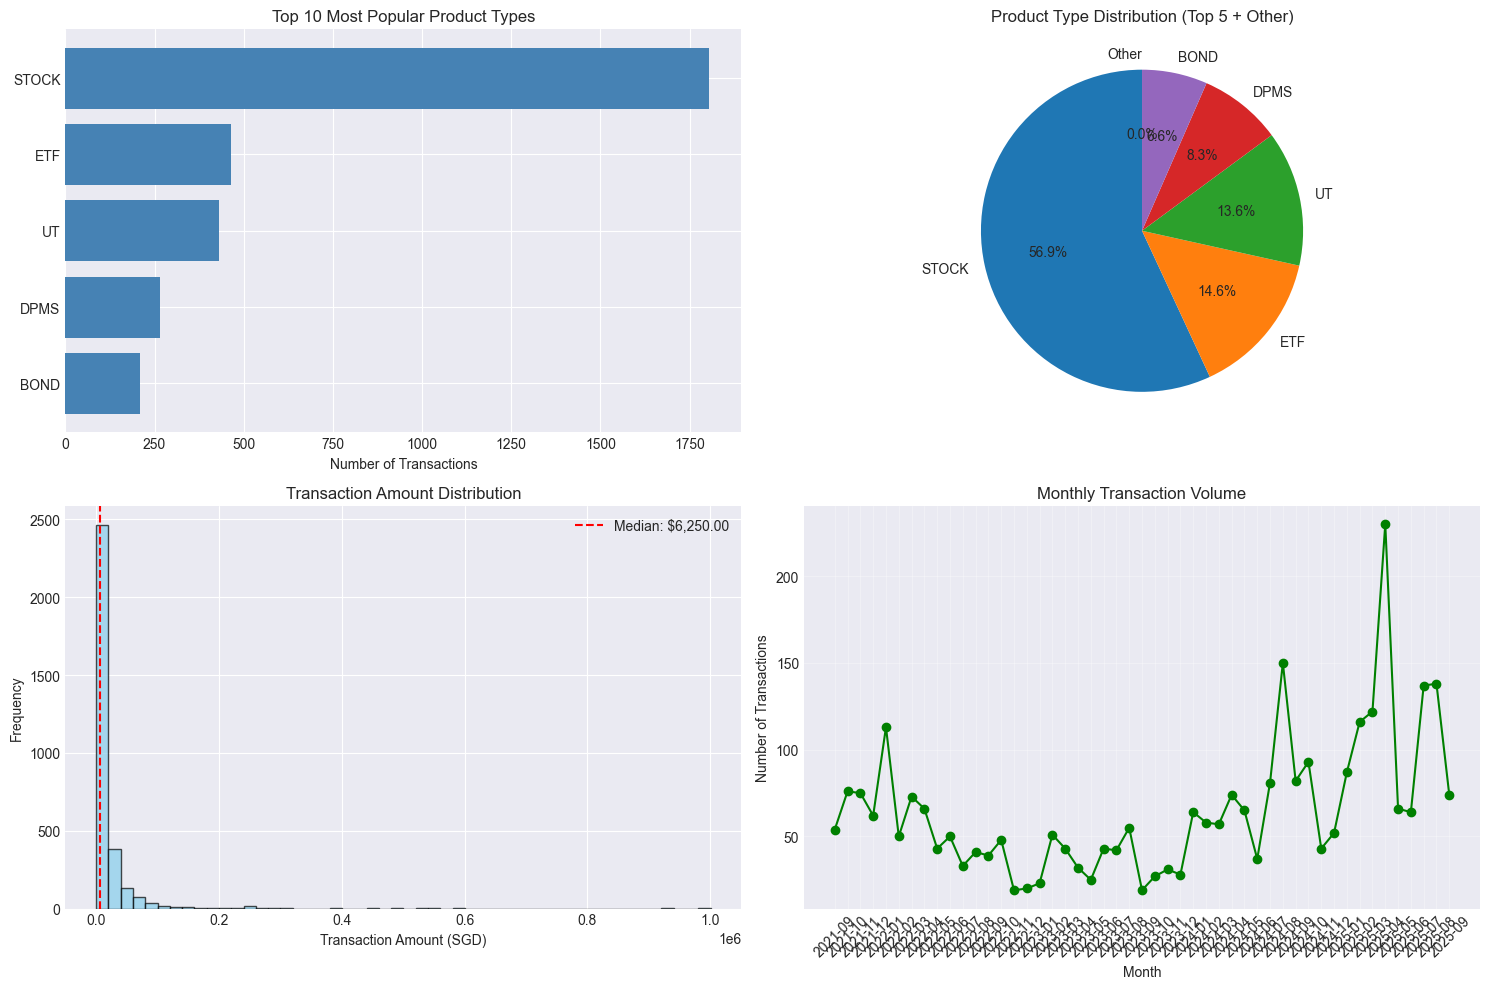


 EDA complete!


In [112]:
# Display basic statistics
print("=" * 60)
print("DATASET OVERVIEW")
print("=" * 60)
print(f"\n Shape: {df.shape[0]} transactions × {df.shape[1]} columns")
print(f"\n Date Range: {df['Date'].min().date()} to {df['Date'].max().date()}")
print(f"   Duration: {(df['Date'].max() - df['Date'].min()).days} days")
print(f"\n Unique Clients: {df['Client'].nunique()}")
print(f" Unique Product Types: {df['ProductType'].nunique()}")
print(f"\n Transaction Amount Statistics (SGD):")
print(df['Amount'].describe())

# Visualizations
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# Top 10 Product Types
product_type_counts = df['ProductType'].value_counts().head(10)
axes[0, 0].barh(product_type_counts.index, product_type_counts.values, color='steelblue')
axes[0, 0].set_xlabel('Number of Transactions')
axes[0, 0].set_title('Top 10 Most Popular Product Types')
axes[0, 0].invert_yaxis()

# Product Type Distribution (Pie)
top_5_types = df['ProductType'].value_counts().head(5)
other_count = df['ProductType'].value_counts()[5:].sum()
pie_data = pd.concat([top_5_types, pd.Series({'Other': other_count})])
axes[0, 1].pie(pie_data.values, labels=pie_data.index, autopct='%1.1f%%', startangle=90)
axes[0, 1].set_title('Product Type Distribution (Top 5 + Other)')

# Transaction Amount Distribution
axes[1, 0].hist(df['Amount'], bins=50, color='skyblue', edgecolor='black', alpha=0.7)
axes[1, 0].axvline(df['Amount'].median(), color='red', linestyle='--', 
                    label=f'Median: ${df["Amount"].median():,.2f}')
axes[1, 0].set_xlabel('Transaction Amount (SGD)')
axes[1, 0].set_ylabel('Frequency')
axes[1, 0].set_title('Transaction Amount Distribution')
axes[1, 0].legend()

# Monthly Transaction Volume
df['YearMonth'] = df['Date'].dt.to_period('M')
monthly_txns = df.groupby('YearMonth').size()
axes[1, 1].plot(monthly_txns.index.astype(str), monthly_txns.values, marker='o', color='green')
axes[1, 1].set_xlabel('Month')
axes[1, 1].set_ylabel('Number of Transactions')
axes[1, 1].set_title('Monthly Transaction Volume')
axes[1, 1].tick_params(axis='x', rotation=45)
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\n EDA complete!")

In [113]:
# Calculate client-level features
print(" Engineering client-level features...")

client_features = df.groupby('Client').agg({
    'Amount': ['mean', 'median', 'std', 'sum', 'count'],
    'Date': ['min', 'max'],
    'ProductType': lambda x: x.value_counts().index[0] if len(x) > 0 else None  # Most frequent
}).reset_index()

client_features.columns = ['Client', 'Avg_Amount', 'Median_Amount', 'Std_Amount', 
                           'Total_Invested', 'Num_Transactions', 'First_Transaction', 
                           'Last_Transaction', 'Favorite_ProductType']

# Calculate derived features
client_features['Days_Active'] = (client_features['Last_Transaction'] - 
                                  client_features['First_Transaction']).dt.days

# Calculate unique product types per client
unique_types = df.groupby('Client')['ProductType'].nunique().reset_index()
unique_types.columns = ['Client', 'Unique_ProductTypes']
client_features = client_features.merge(unique_types, on='Client')

# Calculate average days between purchases
df_sorted = df.sort_values(['Client', 'Date'])
df_sorted['Days_Since_Last'] = df_sorted.groupby('Client')['Date'].diff().dt.days

avg_days_between = df_sorted.groupby('Client')['Days_Since_Last'].agg(['mean', 'median']).reset_index()
avg_days_between.columns = ['Client', 'Avg_Days_Between_Purchases', 'Median_Days_Between_Purchases']
client_features = client_features.merge(avg_days_between, on='Client')

# Fill NaN values for clients with single transaction
client_features['Avg_Days_Between_Purchases'].fillna(30, inplace=True)
client_features['Median_Days_Between_Purchases'].fillna(30, inplace=True)

print(f" Client features created: {len(client_features)} clients")
print("\n Sample of client features:")
client_features.head()

 Engineering client-level features...
 Client features created: 190 clients

 Sample of client features:


,Client,Avg_Amount,Median_Amount,Std_Amount,Total_Invested,Num_Transactions,First_Transaction,Last_Transaction,Favorite_ProductType,Days_Active,Unique_ProductTypes,Avg_Days_Between_Purchases,Median_Days_Between_Purchases
0,B1,1827.76375,1241.015,1847.713183,14622.11,8,2021-10-29,2022-09-01,DPMS,307,3,43.857143,7.0
1,B10,44893.01670,25514.280,49273.928380,4489301.67,100,2021-09-07,2025-09-25,STOCK,1479,3,14.939394,6.0
2,B100,674.08600,593.190,310.930473,3370.43,5,2022-04-05,2022-08-18,ETF,135,2,33.750000,22.0
3,B101,10074.42000,10074.420,NaN,10074.42,1,2022-04-08,2022-04-08,ETF,0,1,30.000000,30.0
4,B102,35301.87000,30601.910,22719.428171,105905.61,3,2022-04-12,2024-04-01,DPMS,720,1,360.000000,360.0


In [114]:
# Calculate product type level features
print(" Engineering product type features...")

product_type_features = df.groupby('ProductType').agg({
    'Amount': ['mean', 'median', 'count'],
    'Client': lambda x: x.nunique()
}).reset_index()

product_type_features.columns = ['ProductType', 'Avg_ProductType_Amount', 
                                  'Median_ProductType_Amount', 'ProductType_Popularity', 
                                  'Unique_Buyers']

print(f" Product type features created: {len(product_type_features)} product types")
print("\n Product type features:")
print(product_type_features.sort_values('ProductType_Popularity', ascending=False).head(10))

 Engineering product type features...
 Product type features created: 5 product types

 Product type features:
  ProductType  Avg_ProductType_Amount  Median_ProductType_Amount  \
3       STOCK            13826.627684                    5031.08   
2         ETF            18640.735356                    4834.77   
4          UT            23446.861836                    5000.00   
1        DPMS            24952.225038                   15300.00   
0        BOND            52985.092500                   20423.60   

   ProductType_Popularity  Unique_Buyers  
3                    1805             91  
2                     463             75  
4                     431             65  
1                     264             89  
0                     208             35  


 Performing Customer Clustering...
 Filtering: 190 total → 152 multi-transaction customers


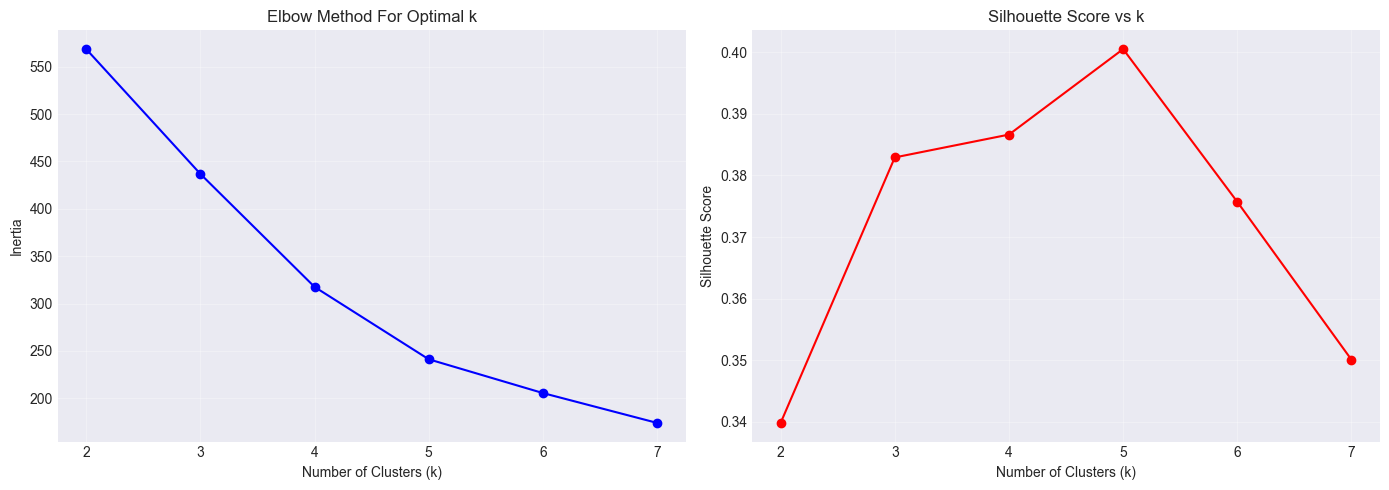


 Multi-transaction customers segmented into 4 clusters (with 3 merged into 1)
   Single-transaction customers: 38 → Cluster 5

 Cluster Distribution (by numeric label):
Cluster
0     48
1    103
2      1
5     38
Name: count, dtype: int64

🔍 Multi-Transaction Cluster Characteristics:
         Avg_Amount  Num_Transactions  Total_Invested  Unique_ProductTypes  \
Cluster                                                                      
0          17773.53             12.21       204108.27                 1.96   
1          26816.94             24.70       467583.69                 2.15   
2         820498.67              3.00      2461496.00                 2.00   

         Avg_Days_Between_Purchases  
Cluster                              
0                            226.21  
1                             28.29  
2                            485.00  

 Final Cluster Names (merged):
   Regular Retail Investor: 103 customers
   Passive Long-Term Investor: 48 customers
   New/Single-T

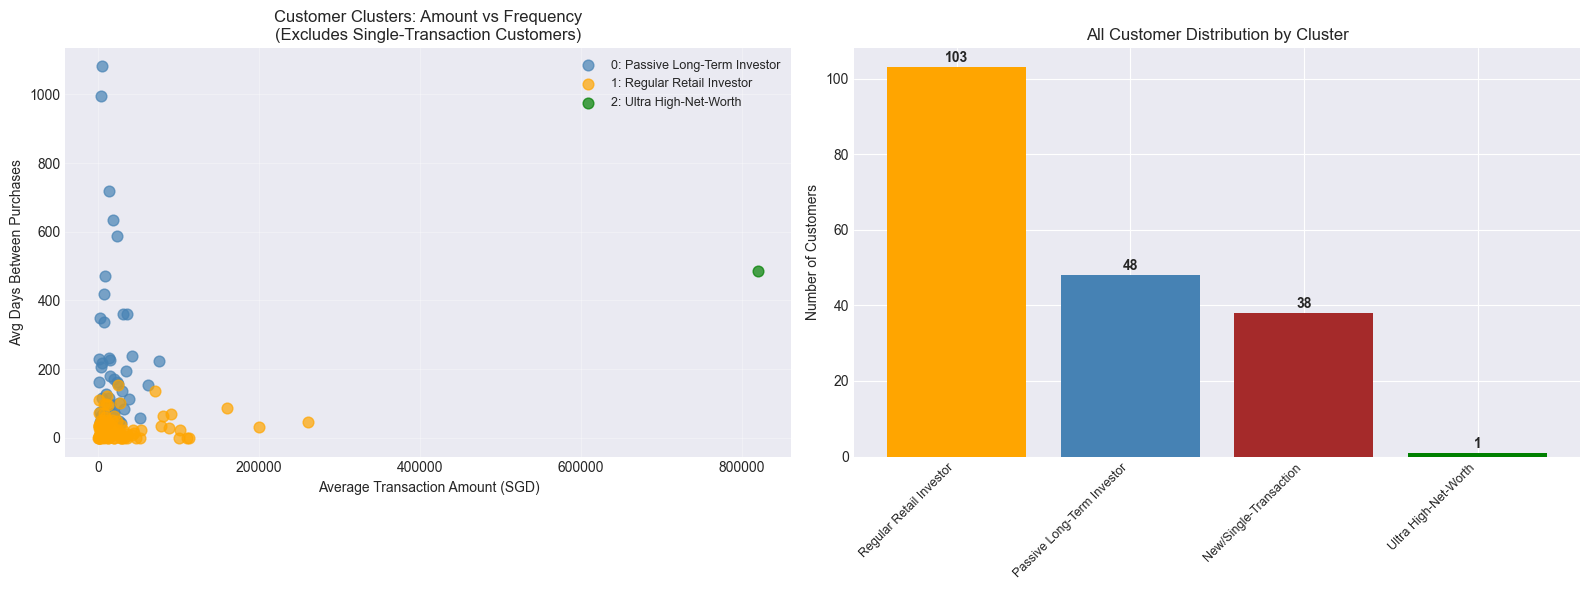


 Clustering complete!
   Multi-transaction customers: 152 (used for clustering)
   Single-transaction customers: 38 (separate group)


In [115]:
# ========================================
# CUSTOMER CLUSTERING (FIXED)
# ========================================
print(" Performing Customer Clustering...")

# FILTER OUT customers with only 1 transaction for clustering
multi_transaction_clients = client_features[client_features['Num_Transactions'] > 1].copy()
print(f" Filtering: {len(client_features)} total → {len(multi_transaction_clients)} multi-transaction customers")

# Prepare features for clustering (only multi-transaction customers)
clustering_features = multi_transaction_clients[['Avg_Amount', 'Num_Transactions', 
                                                'Unique_ProductTypes', 'Days_Active',
                                                'Avg_Days_Between_Purchases']].copy()

# Handle any remaining NaN values
clustering_features = clustering_features.fillna(clustering_features.median())

# Standardize features
scaler = StandardScaler()
clustering_features_scaled = scaler.fit_transform(clustering_features)

# Determine optimal number of clusters using elbow method
inertias = []
silhouette_scores = []
K_range = range(2, 8)  # Extended range for 5+ clusters

from sklearn.metrics import silhouette_score

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(clustering_features_scaled)
    inertias.append(kmeans.inertia_)
    silhouette_scores.append(silhouette_score(clustering_features_scaled, kmeans.labels_))

# Plot elbow curve
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(K_range, inertias, 'bo-')
axes[0].set_xlabel('Number of Clusters (k)')
axes[0].set_ylabel('Inertia')
axes[0].set_title('Elbow Method For Optimal k')
axes[0].grid(True, alpha=0.3)

axes[1].plot(K_range, silhouette_scores, 'ro-')
axes[1].set_xlabel('Number of Clusters (k)')
axes[1].set_ylabel('Silhouette Score')
axes[1].set_title('Silhouette Score vs k')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Perform clustering with k=4
optimal_k = 4
kmeans_final = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
multi_transaction_clients['Cluster'] = kmeans_final.fit_predict(clustering_features_scaled)

# Merge cluster 3 into cluster 1 (per naming decision)
multi_transaction_clients['Cluster'] = multi_transaction_clients['Cluster'].replace({3: 1})

# Assign clusters back to all clients
client_features['Cluster'] = -1  # Initialize
client_features.loc[client_features['Client'].isin(multi_transaction_clients['Client']), 'Cluster'] = \
    multi_transaction_clients.set_index('Client').loc[client_features[client_features['Client'].isin(multi_transaction_clients['Client'])]['Client'], 'Cluster'].values

# Single transaction customers get cluster 5
client_features.loc[client_features['Num_Transactions'] == 1, 'Cluster'] = 5

# Analyze clusters (only multi-transaction ones for main analysis)
print(f"\n Multi-transaction customers segmented into {optimal_k} clusters (with 3 merged into 1)")
print(f"   Single-transaction customers: {len(client_features[client_features['Num_Transactions'] == 1])} → Cluster 5\n")

print(" Cluster Distribution (by numeric label):")
print(client_features['Cluster'].value_counts().sort_index())

print("\n🔍 Multi-Transaction Cluster Characteristics:")
cluster_summary = multi_transaction_clients.groupby('Cluster').agg({
    'Avg_Amount': 'mean',
    'Num_Transactions': 'mean',
    'Total_Invested': 'mean',
    'Unique_ProductTypes': 'mean',
    'Avg_Days_Between_Purchases': 'mean'
}).round(2)

print(cluster_summary)

# Map KMeans labels directly to requested names (with 1 absorbing 3) and keep Single-Transaction
cluster_names = {
    0: "Passive Long-Term Investor",
    1: "Regular Retail Investor",
    2: "Ultra High-Net-Worth",
    5: "New/Single-Transaction"
}

# Apply names to all customers
client_features['Cluster_Name'] = client_features['Cluster'].map(cluster_names)

print("\n Final Cluster Names (merged):")
for label_name, count in client_features['Cluster_Name'].value_counts().items():
    print(f"   {label_name}: {count} customers")

# Visualize clusters (exclude single-transaction customers from scatter plot)
fig = plt.figure(figsize=(16, 6))

# 2D visualization (Amount vs Frequency) - only multi-transaction
ax1 = fig.add_subplot(121)
colors = ['steelblue', 'orange', 'green', 'red', 'purple', 'brown']
for cluster_id in sorted(multi_transaction_clients['Cluster'].unique()):
    cluster_data = multi_transaction_clients[multi_transaction_clients['Cluster'] == cluster_id]
    if len(cluster_data) > 0 and cluster_id in [0, 1, 2]:
        ax1.scatter(cluster_data['Avg_Amount'], cluster_data['Avg_Days_Between_Purchases'],
                   label=f"{cluster_id}: {cluster_names.get(cluster_id, str(cluster_id))}", 
                   alpha=0.7, s=60, color=colors[cluster_id])

ax1.set_xlabel('Average Transaction Amount (SGD)')
ax1.set_ylabel('Avg Days Between Purchases')
ax1.set_title('Customer Clusters: Amount vs Frequency\n(Excludes Single-Transaction Customers)')
ax1.legend(fontsize=9, loc='upper right')
ax1.grid(True, alpha=0.3)

# Cluster distribution - ALL customers including single-transaction
ax2 = fig.add_subplot(122)
cluster_counts = client_features['Cluster_Name'].value_counts()

# Match colors to clusters (fallback gray for Single-Transaction)
name_to_cid = {v: k for k, v in cluster_names.items()}
bar_colors = []
for name in cluster_counts.index:
    cid = name_to_cid.get(name, None)
    if cid is not None and cid < len(colors):
        bar_colors.append(colors[cid])
    else:
        bar_colors.append('gray')

bars = ax2.bar(range(len(cluster_counts)), cluster_counts.values, color=bar_colors)
ax2.set_xticks(range(len(cluster_counts)))
ax2.set_xticklabels(cluster_counts.index, rotation=45, ha='right', fontsize=9)
ax2.set_ylabel('Number of Customers')
ax2.set_title('All Customer Distribution by Cluster')

for bar, count in zip(bars, cluster_counts.values):
    height = bar.get_height()
    ax2.text(bar.get_x() + bar.get_width()/2., height + 0.5, str(count), 
             ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.show()

print(f"\n Clustering complete!")
print(f"   Multi-transaction customers: {len(multi_transaction_clients)} (used for clustering)")
print(f"   Single-transaction customers: {len(client_features[client_features['Num_Transactions'] == 1])} (separate group)")

In [116]:
# Merge all features into enhanced dataframe
print(" Creating enhanced dataset...")

df_enhanced = df.merge(client_features[['Client', 'Avg_Amount', 'Median_Amount', 
                                         'Num_Transactions', 'Unique_ProductTypes', 
                                         'Favorite_ProductType', 'Days_Active',
                                         'Avg_Days_Between_Purchases', 'Cluster', 
                                         'Cluster_Name']], 
                       on='Client', how='left')

df_enhanced = df_enhanced.merge(product_type_features, on='ProductType', how='left')

# Add temporal features
df_enhanced['DayOfWeek'] = df_enhanced['Date'].dt.dayofweek
df_enhanced['Month'] = df_enhanced['Date'].dt.month
df_enhanced['Quarter'] = df_enhanced['Date'].dt.quarter

print(f" Enhanced dataset created: {df_enhanced.shape}")
print("\n Sample of enhanced data:")
df_enhanced.head()

 Creating enhanced dataset...
 Enhanced dataset created: (3171, 24)

 Sample of enhanced data:


,Client,Product,ProductType,Date,Amount,Issuer,Category,YearMonth,Avg_Amount,Median_Amount,Num_Transactions,Unique_ProductTypes,Favorite_ProductType,Days_Active,Avg_Days_Between_Purchases,Cluster,Cluster_Name,Avg_ProductType_Amount,Median_ProductType_Amount,ProductType_Popularity,Unique_Buyers,DayOfWeek,Month,Quarter
0,B1,DPMS Capital Growth IGP (Aggressive),DPMS,2021-10-29,3500.00,-,Aggressive,2021-10,1827.76375,1241.015,8,3,DPMS,307,43.857143,1,Regular Retail Investor,24952.225038,15300.00,264,89,4,10,4
1,B1,DPMS Capital Growth IGP (Aggressive),DPMS,2022-02-28,2000.00,-,Aggressive,2022-02,1827.76375,1241.015,8,3,DPMS,307,43.857143,1,Regular Retail Investor,24952.225038,15300.00,264,89,0,2,1
2,B1,DPMS Capital Growth IGP (Aggressive),DPMS,2022-06-02,5000.00,-,Aggressive,2022-06,1827.76375,1241.015,8,3,DPMS,307,43.857143,1,Regular Retail Investor,24952.225038,15300.00,264,89,3,6,2
3,B1,DigiCore Reit USD,STOCK,2022-08-18,249.85,SGX,Equity,2022-08,1827.76375,1241.015,8,3,DPMS,307,43.857143,1,Regular Retail Investor,13826.627684,5031.08,1805,91,3,8,3
4,B1,DPMS Capital Growth IGP (Aggressive),DPMS,2022-08-18,3000.00,-,Aggressive,2022-08,1827.76375,1241.015,8,3,DPMS,307,43.857143,1,Regular Retail Investor,24952.225038,15300.00,264,89,3,8,3


 Visualizing transaction amount distributions by cluster...


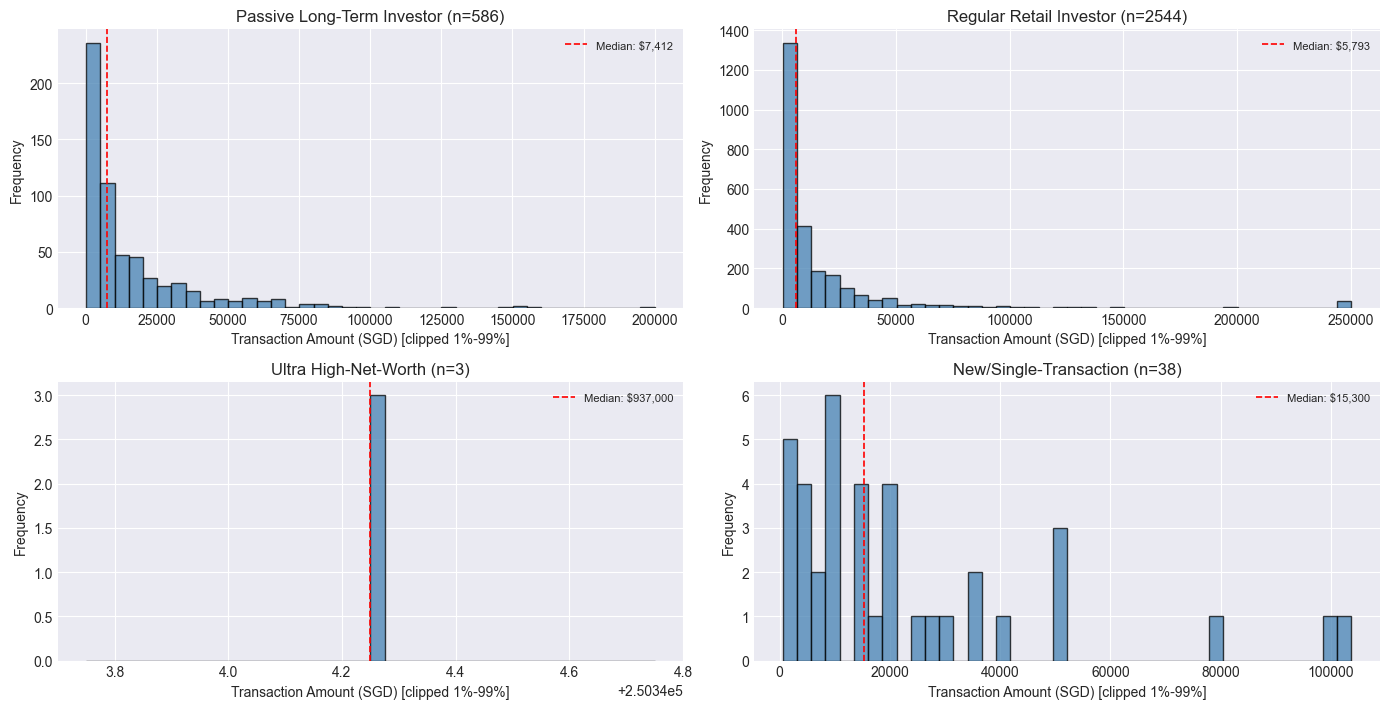

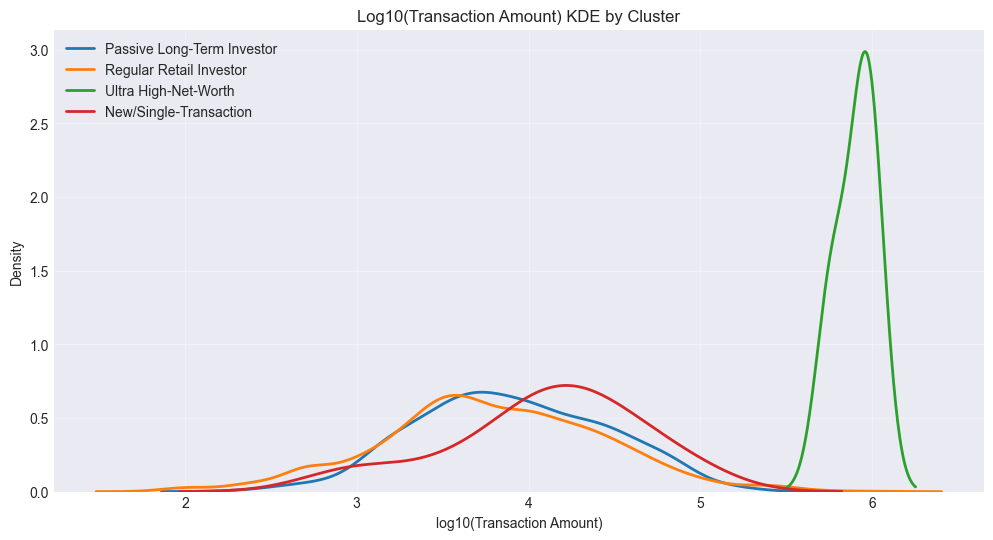

 Done: cluster-wise amount distribution plots ready.


In [117]:
# Transaction Amount Distributions per Cluster
print(" Visualizing transaction amount distributions by cluster...")

# Ensure enhanced dataframe exists with Cluster_Name
assert 'df_enhanced' in globals(), "df_enhanced not found. Run the feature merge cell first."

# Prepare data
plot_df = df_enhanced[['Amount', 'Cluster_Name']].dropna().copy()

# Keep only defined cluster names
valid_clusters = [
    "Passive Long-Term Investor",
    "Regular Retail Investor",
    "Ultra High-Net-Worth",
    "New/Single-Transaction",
]
plot_df = plot_df[plot_df['Cluster_Name'].isin(valid_clusters)]

# Optional: create a clipped amount for visualization stability (reduce extreme tail effects)
clip_low, clip_high = plot_df['Amount'].quantile([0.01, 0.99]).values
plot_df['Amount_Clipped'] = plot_df['Amount'].clip(lower=clip_low, upper=clip_high)
plot_df['Log10_Amount'] = np.log10(plot_df['Amount'].where(plot_df['Amount'] > 0))

# 1) Histograms per cluster (clipped)
import math
clusters_in_data = list(plot_df['Cluster_Name'].unique())
clusters_in_data.sort(key=lambda x: valid_clusters.index(x))

n = len(clusters_in_data)
cols = 2
rows = math.ceil(n / cols)

fig, axes = plt.subplots(rows, cols, figsize=(14, 3.6 * rows))
axes = axes.flatten() if n > 1 else [axes]

for i, cname in enumerate(clusters_in_data):
    ax = axes[i]
    sub = plot_df[plot_df['Cluster_Name'] == cname]
    ax.hist(sub['Amount_Clipped'], bins=40, color='steelblue', alpha=0.75, edgecolor='black')
    ax.axvline(sub['Amount_Clipped'].median(), color='red', linestyle='--', linewidth=1.2, label=f"Median: ${sub['Amount'].median():,.0f}")
    ax.set_title(f"{cname} (n={len(sub)})")
    ax.set_xlabel('Transaction Amount (SGD) [clipped 1%-99%]')
    ax.set_ylabel('Frequency')
    ax.legend(fontsize=8)

# Hide any unused subplots
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

# 2) KDEs on log10 scale (overlayed)
plt.figure(figsize=(12, 6))
for cname in clusters_in_data:
    sub = plot_df[plot_df['Cluster_Name'] == cname]
    # Guard for small groups
    if sub['Log10_Amount'].notna().sum() > 2:
        sns.kdeplot(sub['Log10_Amount'].dropna(), label=cname, fill=False, linewidth=2)

plt.title('Log10(Transaction Amount) KDE by Cluster')
plt.xlabel('log10(Transaction Amount)')
plt.ylabel('Density')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

print(" Done: cluster-wise amount distribution plots ready.")

In [118]:
# Analyze product transitions (using actual product names)
print(" Analyzing product transitions...")

transitions = []

for client in df['Client'].unique():
    client_data = df[df['Client'] == client].sort_values('Date')
    
    for i in range(len(client_data) - 1):
        from_product = client_data.iloc[i]['Product']
        to_product = client_data.iloc[i + 1]['Product']
        from_type = client_data.iloc[i]['ProductType']
        to_type = client_data.iloc[i + 1]['ProductType']
        
        # Track all product-to-product transitions (including same type)
        if from_product != to_product:
            transitions.append({
                'Client': client,
                'From_Product': from_product,
                'To_Product': to_product,
                'From_ProductType': from_type,
                'To_ProductType': to_type
            })

transitions_df = pd.DataFrame(transitions)

print(f" Identified {len(transitions_df)} product transitions")

# Calculate transition probabilities BY PRODUCT TYPE
if len(transitions_df) > 0:
    # Group by product type transitions
    transition_counts = transitions_df.groupby(['From_ProductType', 'To_ProductType']).size().reset_index(name='Count')
    total_from = transitions_df.groupby('From_ProductType').size().reset_index(name='Total')
    
    transition_probs = transition_counts.merge(total_from, on='From_ProductType')
    transition_probs['Probability'] = transition_probs['Count'] / transition_probs['Total']
    transition_probs = transition_probs.sort_values('Probability', ascending=False)
    
    print("\n Top 15 Product Type Transitions:")
    print(transition_probs[['From_ProductType', 'To_ProductType', 'Count', 'Probability']].head(15))
    
    # Also show sample of actual product transitions
    print("\n Sample Product-Level Transitions:")
    sample_transitions = transitions_df[['From_Product', 'To_Product', 'From_ProductType', 'To_ProductType']].head(10)
    print(sample_transitions)
else:
    transition_probs = pd.DataFrame(columns=['From_ProductType', 'To_ProductType', 'Count', 'Probability'])
    print(" No transitions found")

 Analyzing product transitions...
 Identified 2281 product transitions

 Top 15 Product Type Transitions:
   From_ProductType To_ProductType  Count  Probability
18            STOCK          STOCK   1090     0.831426
0              BOND           BOND    145     0.771277
24               UT             UT    203     0.738182
12              ETF            ETF    149     0.425714
13              ETF          STOCK    144     0.411429
6              DPMS           DPMS     51     0.324841
8              DPMS          STOCK     38     0.242038
7              DPMS            ETF     35     0.222930
9              DPMS             UT     25     0.159236
3              BOND          STOCK     21     0.111702
17            STOCK            ETF    141     0.107551
23               UT          STOCK     27     0.098182
21               UT           DPMS     25     0.090909
11              ETF           DPMS     31     0.088571
1              BOND           DPMS     12     0.063830

 Sample Produ

 Performing market basket analysis...
 Found 31 frequent product type combinations
 Generated 115 association rules


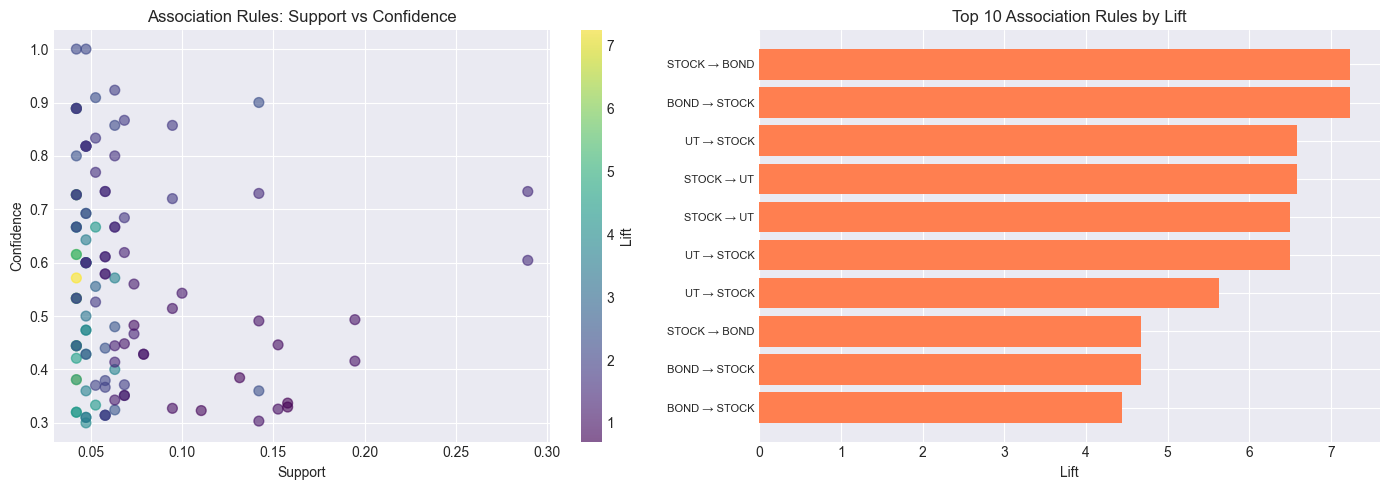

In [119]:
# Market basket analysis using product types
print(" Performing market basket analysis...")

# Create baskets (list of product types per client)
baskets = df.groupby('Client')['ProductType'].apply(list).values.tolist()

# Encode transactions
te = TransactionEncoder()
te_ary = te.fit(baskets).transform(baskets)
basket_df = pd.DataFrame(te_ary, columns=te.columns_)

# Apply Apriori algorithm
frequent_itemsets = apriori(basket_df, min_support=0.02, use_colnames=True)

if len(frequent_itemsets) > 0:
    print(f" Found {len(frequent_itemsets)} frequent product type combinations")
    
    # Generate association rules
    rules = association_rules(frequent_itemsets, metric="confidence", min_threshold=0.3)
    rules = rules.sort_values('lift', ascending=False)
    
    print(f" Generated {len(rules)} association rules")
    
    # Visualize
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    # Support vs Confidence
    scatter = axes[0].scatter(rules['support'], rules['confidence'], 
                             c=rules['lift'], cmap='viridis', alpha=0.6, s=50)
    axes[0].set_xlabel('Support')
    axes[0].set_ylabel('Confidence')
    axes[0].set_title('Association Rules: Support vs Confidence')
    plt.colorbar(scatter, ax=axes[0], label='Lift')
    
    # Top rules by lift
    top_rules = rules.head(10)
    axes[1].barh(range(len(top_rules)), top_rules['lift'].values, color='coral')
    axes[1].set_yticks(range(len(top_rules)))
    axes[1].set_yticklabels([f"{list(r['antecedents'])[0]} → {list(r['consequents'])[0]}" 
                             for _, r in top_rules.iterrows()], fontsize=8)
    axes[1].set_xlabel('Lift')
    axes[1].set_title('Top 10 Association Rules by Lift')
    axes[1].invert_yaxis()
    
    plt.tight_layout()
    plt.show()
    
    # print("\n Top 10 Association Rules:")
    # for idx, row in rules.head(10).iterrows():
    #     print(f"   {list(row['antecedents'])} → {list(row['consequents'])}")
    #     print(f"   Support: {row['support']:.3f} | Confidence: {row['confidence']:.3f} | Lift: {row['lift']:.3f}\n")
else:
    rules = pd.DataFrame()
    print(" No frequent itemsets found with min_support=0.02")

 Training hierarchical quantile models for amount recommendation...

 Model Performance (test, P50):
   MAE:  $9,206.06
   RMSE: $21,209.90
   R²:   0.8891


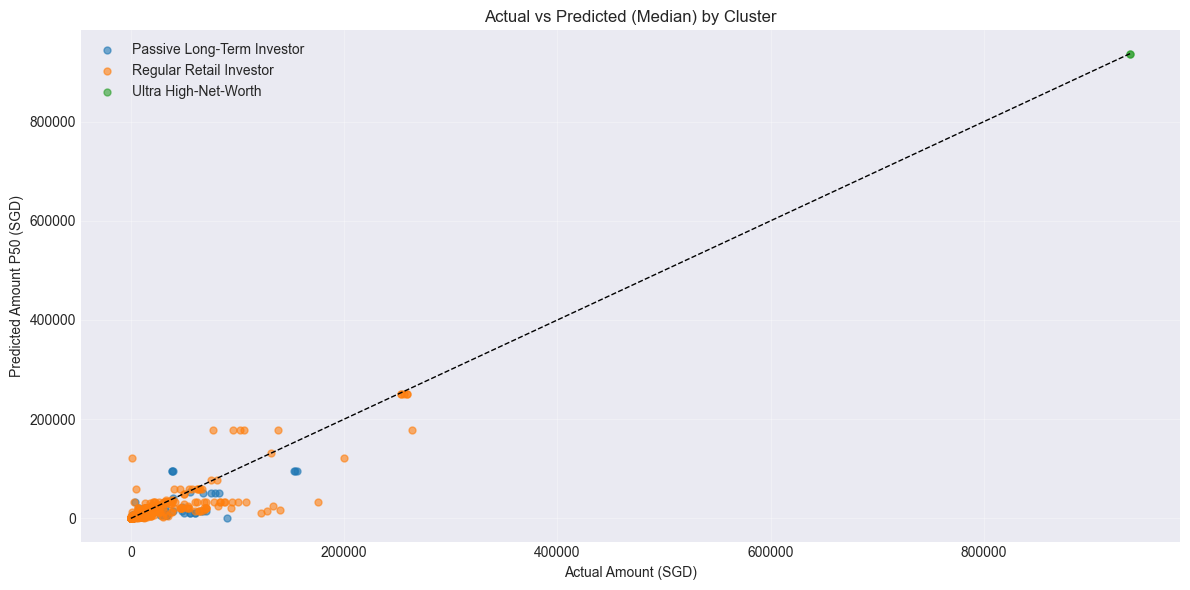


 Price recommendations created for 190 clients
 Merged price quantiles into recommendations_df
 Done: hierarchical price recommendation pipeline ready.


In [120]:
# Hierarchical price recommendation: client baseline + cluster quantile models
print(" Training hierarchical quantile models for amount recommendation...")

# 1) Build robust baselines per client (and as fallback per cluster/product type)
client_median = df.groupby(['Client'])['Amount'].median().rename('Client_Median')
client_ewm = df.sort_values(['Client','Date']).groupby('Client')['Amount'].apply(
    lambda s: s.ewm(alpha=0.3).mean().iloc[-1] if len(s) else np.nan
).rename('Client_EWMA')

# Per product-type within client (last value and median)
last_amount_by_client_type = df.sort_values('Date').groupby(['Client','ProductType'])['Amount'].last().rename('Last_Amount_ClientType')
median_by_client_type = df.groupby(['Client','ProductType'])['Amount'].median().rename('Median_Amount_ClientType')

# Per-cluster medians (using current Cluster_Name on client_features)
cluster_by_client = client_features.set_index('Client')['Cluster_Name']
cluster_median = df.join(cluster_by_client, on='Client').groupby('Cluster_Name')['Amount'].median().rename('Cluster_Median')
ptype_median = df.groupby('ProductType')['Amount'].median().rename('ProductType_Median')

df_enhanced = df_enhanced.copy()

# Attach baselines to each row contextually (use current row's ProductType)
df_enhanced = df_enhanced.join(client_median, on='Client')
df_enhanced = df_enhanced.join(client_ewm, on='Client')
df_enhanced = df_enhanced.join(last_amount_by_client_type, on=['Client','ProductType'])
df_enhanced = df_enhanced.join(median_by_client_type, on=['Client','ProductType'])
df_enhanced = df_enhanced.join(cluster_by_client.rename('Cluster_Name_FromClient'), on='Client')
df_enhanced = df_enhanced.join(cluster_median, on='Cluster_Name_FromClient')
df_enhanced = df_enhanced.join(ptype_median, on='ProductType')

# Compose a primary baseline per row (priority: client-type median -> client EWMA -> client median -> cluster median -> product-type median)
df_enhanced['Baseline_Amount'] = (
    df_enhanced['Median_Amount_ClientType'].fillna(df_enhanced['Client_EWMA'])
                                         .fillna(df_enhanced['Client_Median'])
                                         .fillna(df_enhanced['Cluster_Median'])
                                         .fillna(df_enhanced['ProductType_Median'])
)

# 2) Feature set for residual models
le = LabelEncoder()
df_enhanced['ProductType_Encoded'] = le.fit_transform(df_enhanced['ProductType'])

base_cols = [
    'Baseline_Amount', 'Avg_Amount', 'Median_Amount', 'Num_Transactions',
    'Unique_ProductTypes', 'Avg_ProductType_Amount', 'ProductType_Popularity',
    'DayOfWeek', 'Month', 'Quarter', 'ProductType_Encoded'
]

# Ensure needed columns exist and handle missing
for c in base_cols:
    if c not in df_enhanced.columns:
        df_enhanced[c] = np.nan

feat_df = df_enhanced[base_cols + ['Client','Date','Amount','Cluster_Name']].copy()
feat_df[base_cols] = feat_df[base_cols].fillna(feat_df[base_cols].median(numeric_only=True))

# Residual target
feat_df['Residual'] = feat_df['Amount'] - feat_df['Baseline_Amount']

# Time-based split (use last 20% by date as test)
cutoff_date = feat_df['Date'].quantile(0.8)
train_df = feat_df[feat_df['Date'] <= cutoff_date]
test_df = feat_df[feat_df['Date'] > cutoff_date]

clusters_to_model = ['Passive Long-Term Investor','Regular Retail Investor','Ultra High-Net-Worth']
quantiles = [0.1, 0.5, 0.9]

models = {cn: {} for cn in clusters_to_model}

# 3) Train cluster-specific quantile models on residuals
from sklearn.ensemble import GradientBoostingRegressor

for cn in clusters_to_model:
    tr_c = train_df[train_df['Cluster_Name'] == cn]
    if len(tr_c) < 50:
        continue
    X_tr = tr_c[base_cols]
    y_tr = tr_c['Residual']
    for q in quantiles:
        gbr = GradientBoostingRegressor(loss='quantile', alpha=q, random_state=42)
        gbr.fit(X_tr, y_tr)
        models[cn][q] = gbr

# 4) Predict on test set and evaluate
preds = []
for _, row in test_df.iterrows():
    cn = row['Cluster_Name']
    base = row['Baseline_Amount']
    x = row[base_cols].values.reshape(1, -1)
    if cn in models and 0.5 in models[cn]:
        p10 = base + models[cn].get(0.1, models[cn][0.5]).predict(x)[0]
        p50 = base + models[cn][0.5].predict(x)[0]
        p90 = base + models[cn].get(0.9, models[cn][0.5]).predict(x)[0]
    else:
        # Fallback to baselines if no model for cluster
        p10 = base
        p50 = base
        p90 = base
    preds.append((row['Client'], row['Date'], row['Amount'], cn, base, p10, p50, p90))

preds_df = pd.DataFrame(preds, columns=['Client','Date','Actual','Cluster_Name','Baseline','P10','P50','P90'])

# Metrics on median prediction
if not preds_df.empty:
    mae = mean_absolute_error(preds_df['Actual'], preds_df['P50'])
    rmse = np.sqrt(mean_squared_error(preds_df['Actual'], preds_df['P50']))
    # r2 on P50
    r2 = r2_score(preds_df['Actual'], preds_df['P50'])
else:
    mae = np.nan
    rmse = np.nan
    r2 = np.nan

print(f"\n Model Performance (test, P50):")
print(f"   MAE:  ${mae:,.2f}")
print(f"   RMSE: ${rmse:,.2f}")
print(f"   R²:   {0 if np.isnan(r2) else r2:.4f}")

# 5) Visualization: Actual vs Predicted (P50) by cluster
if not preds_df.empty:
    plt.figure(figsize=(12,6))
    for cn in clusters_to_model:
        sub = preds_df[preds_df['Cluster_Name'] == cn]
        if len(sub) > 0:
            plt.scatter(sub['Actual'], sub['P50'], alpha=0.6, label=cn, s=25)
    max_val = np.nanmax(preds_df[['Actual','P50']].values)
    plt.plot([0, max_val], [0, max_val], 'k--', linewidth=1)
    plt.xlabel('Actual Amount (SGD)')
    plt.ylabel('Predicted Amount P50 (SGD)')
    plt.title('Actual vs Predicted (Median) by Cluster')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

# 6) Assemble price recommendations for next purchase per client (using latest row per client)
latest_by_client = feat_df.sort_values('Date').groupby('Client').tail(1)
price_recos = []
for _, row in latest_by_client.iterrows():
    cn = row['Cluster_Name']
    base = row['Baseline_Amount']
    x = row[base_cols].values.reshape(1, -1)
    if cn in models and 0.5 in models[cn]:
        p10 = base + models[cn].get(0.1, models[cn][0.5]).predict(x)[0]
        p50 = base + models[cn][0.5].predict(x)[0]
        p90 = base + models[cn].get(0.9, models[cn][0.5]).predict(x)[0]
    else:
        p10 = base
        p50 = base
        p90 = base
    price_recos.append({
        'Client': row['Client'],
        'Cluster_Name': cn,
        'Recommended_Amount_P10': p10,
        'Recommended_Amount_P50': p50,
        'Recommended_Amount_P90': p90,
        'Baseline_Amount': base
    })
price_recos_df = pd.DataFrame(price_recos)

print(f"\n Price recommendations created for {len(price_recos_df)} clients")

# 7) If recommendations_df exists, merge amounts into it
if 'recommendations_df' in globals():
    recommendations_df = recommendations_df.drop(columns=[
        c for c in ['Predicted_Amount_SGD'] if c in recommendations_df.columns
    ], errors='ignore')
    recommendations_df = recommendations_df.merge(
        price_recos_df[['Client','Recommended_Amount_P10','Recommended_Amount_P50','Recommended_Amount_P90']],
        on='Client', how='left'
    )
    print(" Merged price quantiles into recommendations_df")

print(" Done: hierarchical price recommendation pipeline ready.")

In [121]:
# Predict next purchase timing
print(" Predicting next purchase timing...")

df_sorted = df.sort_values(['Client', 'Date'])
df_sorted['Days_Since_Last'] = df_sorted.groupby('Client')['Date'].diff().dt.days

next_purchase_predictions = []

for client in client_features['Client'].unique():
    client_data = df_sorted[df_sorted['Client'] == client]
    
    if len(client_data) >= 1:
        last_transaction_date = client_data['Date'].max()
        
        if len(client_data) >= 2:
            avg_interval = client_data['Days_Since_Last'].dropna().mean()
            median_interval = client_data['Days_Since_Last'].dropna().median()
        else:
            avg_interval = 30
            median_interval = 30
        
        predicted_next_date = last_transaction_date + timedelta(days=median_interval)
        
        next_purchase_predictions.append({
            'Client': client,
            'Last_Transaction_Date': last_transaction_date,
            'Avg_Days_Between': avg_interval,
            'Median_Days_Between': median_interval,
            'Predicted_Next_Purchase_Date': predicted_next_date
        })

timing_predictions = pd.DataFrame(next_purchase_predictions)

print(f" Timing predictions generated for {len(timing_predictions)} clients")
print("\n Sample predictions:")
timing_predictions.head(10)

 Predicting next purchase timing...
 Timing predictions generated for 190 clients

 Sample predictions:


,Client,Last_Transaction_Date,Avg_Days_Between,Median_Days_Between,Predicted_Next_Purchase_Date
0,B1,2022-09-01,43.857143,7.0,2022-09-08
1,B10,2025-09-25,14.939394,6.0,2025-10-01
2,B100,2022-08-18,33.750000,22.0,2022-09-09
3,B101,2022-04-08,30.000000,30.0,2022-05-08
4,B102,2024-04-01,360.000000,360.0,2025-03-27
5,B103,2025-04-01,361.666667,365.0,2026-04-01
6,B104,2022-06-23,65.000000,65.0,2022-08-27
7,B105,2025-04-10,1081.000000,1081.0,2028-03-26
8,B106,2022-05-06,30.000000,30.0,2022-06-05
9,B107,2022-05-12,30.000000,30.0,2022-06-11


In [122]:
# ========================================
# FIND SIMILAR CUSTOMERS
# ========================================
print(" Building similar customers functionality...")

def find_similar_customers(target_client, top_n=10):
    """
    Find customers similar to the target customer based on:
    1. Same cluster
    2. Similar spending patterns
    3. Similar product type preferences
    """
    
    # Get target customer info
    target_info = client_features[client_features['Client'] == target_client].iloc[0]
    target_cluster = target_info['Cluster']
    
    # Get customers from same cluster (excluding target)
    same_cluster = client_features[
        (client_features['Cluster'] == target_cluster) & 
        (client_features['Client'] != target_client)
    ].copy()
    
    if len(same_cluster) == 0:
        print(f" No other customers in cluster {target_cluster}")
        return pd.DataFrame()
    
    # Calculate similarity scores
    similarity_scores = []
    
    # Get target's product type preferences
    target_products = set(df[df['Client'] == target_client]['ProductType'].unique())
    
    for _, customer in same_cluster.iterrows():
        customer_id = customer['Client']
        customer_products = set(df[df['Client'] == customer_id]['ProductType'].unique())
        
        # Jaccard similarity for product types
        jaccard_sim = len(target_products & customer_products) / len(target_products | customer_products)
        
        # Spending similarity (inverse of normalized difference)
        spending_diff = abs(target_info['Avg_Amount'] - customer['Avg_Amount'])
        max_spending = max(target_info['Avg_Amount'], customer['Avg_Amount'])
        spending_sim = 1 - (spending_diff / max_spending) if max_spending > 0 else 1
        
        # Frequency similarity
        freq_diff = abs(target_info['Avg_Days_Between_Purchases'] - customer['Avg_Days_Between_Purchases'])
        max_freq = max(target_info['Avg_Days_Between_Purchases'], customer['Avg_Days_Between_Purchases'])
        freq_sim = 1 - (freq_diff / max_freq) if max_freq > 0 else 1
        
        # Combined similarity (weighted average)
        combined_similarity = (0.5 * jaccard_sim + 0.3 * spending_sim + 0.2 * freq_sim)
        
        similarity_scores.append({
            'Client': customer_id,
            'Similarity_Score': combined_similarity,
            'Jaccard_Similarity': jaccard_sim,
            'Spending_Similarity': spending_sim,
            'Frequency_Similarity': freq_sim,
            'Avg_Amount': customer['Avg_Amount'],
            'Num_Transactions': customer['Num_Transactions']
        })
    
    # Sort by similarity
    similar_customers_df = pd.DataFrame(similarity_scores).sort_values(
        'Similarity_Score', ascending=False
    ).head(top_n)
    
    return similar_customers_df

# Test the function
test_client = client_features['Client'].iloc[0]
similar_customers = find_similar_customers(test_client, top_n=10)

print(f"\n Similar customers function created!")
print(f"\n Top 10 customers similar to {test_client}:")
print(similar_customers)

 Building similar customers functionality...

 Similar customers function created!

 Top 10 customers similar to B1:
    Client  Similarity_Score  Jaccard_Similarity  Spending_Similarity  \
42    B177          0.704635            0.666667             0.812047   
71     B25          0.664224            1.000000             0.095859   
7     B119          0.656380            1.000000             0.184566   
77     B37          0.644124            0.750000             0.644630   
79     B42          0.621767            0.750000             0.196474   
100    B94          0.618183            1.000000             0.059523   
99     B93          0.613062            1.000000             0.042455   
1     B100          0.597883            0.666667             0.368804   
82     B52          0.590795            0.750000             0.229568   
72     B28          0.580381            0.750000             0.119638   

     Frequency_Similarity    Avg_Amount  Num_Transactions  
42               0.

In [123]:
# Enhanced Recommendation Engine
print(" Building enhanced recommendation engine...")

def get_recommendations_for_client(client_id):
    """Generate recommendations using multiple signals"""
    
    client_info = client_features[client_features['Client'] == client_id].iloc[0]
    last_product_type = df[df['Client'] == client_id].sort_values('Date').iloc[-1]['ProductType']
    
    # Signal 1: Sequential patterns
    sequential_rec = None
    seq_conf = 0
    next_candidates = transition_probs[transition_probs['From_ProductType'] == last_product_type]
    if not next_candidates.empty:
        sequential_rec = next_candidates.iloc[0]['To_ProductType']
        seq_conf = next_candidates.iloc[0]['Probability']
    
    # Signal 2: Similar customers
    similar_customers = find_similar_customers(client_id, top_n=10)
    similar_rec = None
    sim_conf = 0
    
    if len(similar_customers) > 0:
        similar_client_ids = similar_customers['Client'].tolist()
        similar_products = df[df['Client'].isin(similar_client_ids)]['ProductType'].value_counts()
        client_products = set(df[df['Client'] == client_id]['ProductType'])
        
        for prod_type in similar_products.index:
            if prod_type not in client_products:
                similar_rec = prod_type
                buyers = df[df['Client'].isin(similar_client_ids) & 
                          (df['ProductType'] == prod_type)]['Client'].nunique()
                sim_conf = buyers / len(similar_customers)
                break
    
    # Combine with weighted voting
    recommendations = {}
    if sequential_rec:
        recommendations[sequential_rec] = recommendations.get(sequential_rec, 0) + (0.4 * seq_conf)
    if similar_rec:
        recommendations[similar_rec] = recommendations.get(similar_rec, 0) + (0.6 * sim_conf)
    
    # Fallback: Popular products not yet bought
    if not recommendations:
        all_products = df['ProductType'].value_counts()
        client_products = set(df[df['Client'] == client_id]['ProductType'])
        for prod in all_products.index:
            if prod not in client_products:
                recommendations[prod] = 0.3
                break
    
    # Get top recommendation
    if recommendations:
        top_rec = max(recommendations.items(), key=lambda x: x[1])
        return {
            'recommended_type': top_rec[0],
            'confidence': top_rec[1],
            'sequential_rec': sequential_rec,
            'similar_customers_rec': similar_rec
        }
    
    return None

# Test
test_rec = get_recommendations_for_client(client_features['Client'].iloc[0])
print(f" Recommendation engine ready!")
print(f"\n Sample recommendation: {test_rec}")

 Building enhanced recommendation engine...
 Recommendation engine ready!

 Sample recommendation: {'recommended_type': 'ETF', 'confidence': 0.1702857142857143, 'sequential_rec': 'ETF', 'similar_customers_rec': 'BOND'}


In [124]:
# Generate recommendations for all clients
print(" Generating recommendations for all clients...")

all_recommendations = []

for client in client_features['Client'].unique():
    rec = get_recommendations_for_client(client)
    
    if rec:
        client_info = client_features[client_features['Client'] == client].iloc[0]
        last_txn = df[df['Client'] == client].sort_values('Date').iloc[-1]
        last_product_type = last_txn['ProductType']
        last_product_date = pd.to_datetime(last_txn['Date']).date()
        last_product_amount = float(last_txn['Amount'])
        
        # Predict amount using hierarchical quantile outputs (fallback to baseline if unavailable)
        p10 = p50 = p90 = None
        if 'price_recos_df' in globals():
            recos_row = price_recos_df[price_recos_df['Client'] == client]
            if not recos_row.empty:
                p10 = float(recos_row.iloc[0]['Recommended_Amount_P10'])
                p50 = float(recos_row.iloc[0]['Recommended_Amount_P50'])
                p90 = float(recos_row.iloc[0]['Recommended_Amount_P90'])
        
        # Lightweight baseline fallback if quantiles are missing
        if p50 is None:
            client_hist = df[df['Client'] == client]
            pt_hist = client_hist[client_hist['ProductType'] == last_product_type]
            if len(pt_hist) > 0:
                p50 = float(pt_hist['Amount'].median())
            else:
                p50 = float(client_hist['Amount'].median())
            p10 = p10 if p10 is not None else 0.5 * p50
            p90 = p90 if p90 is not None else 1.5 * p50
        
        # Clamp negatives to zero
        p10 = max(0.0, p10)
        p50 = max(0.0, p50)
        p90 = max(0.0, p90)
        
        # Get timing
        timing_info = timing_predictions[timing_predictions['Client'] == client]
        predicted_date = timing_info.iloc[0]['Predicted_Next_Purchase_Date'] if not timing_info.empty else pd.Timestamp.now() + timedelta(days=30)
        
        all_recommendations.append({
            'Client': client,
            'Cluster': client_info['Cluster_Name'],
            'Current_ProductType': last_product_type,
            'Current_ProductType_Date': last_product_date,
            'Current_ProductType_Amount': last_product_amount,
            'Recommended_ProductType': rec['recommended_type'],
            'Confidence': f"{rec['confidence']:.2%}",
            # Keep legacy column for compatibility, use P50 as central estimate
            'Predicted_Amount_SGD': f"{p50:,.2f}",
            # New quantile outputs
            'Recommended_Amount_P10': p10,
            'Recommended_Amount_P50': p50,
            'Recommended_Amount_P90': p90,
            'Predicted_Purchase_Date': predicted_date.date(),
            'Avg_Historical_Amount': f"{client_info['Avg_Amount']:,.2f}",
            'Total_Transactions': int(client_info['Num_Transactions'])
        })

recommendations_df = pd.DataFrame(all_recommendations)

# Add Top 10% Buyer flag at the end based on Total_Transactions
if len(recommendations_df) > 0:
    threshold = recommendations_df['Total_Transactions'].quantile(0.9)
    recommendations_df['Top_10pct_Buyer'] = recommendations_df['Total_Transactions'] >= threshold

print(f"\n Generated recommendations for {len(recommendations_df)} clients")
recommendations_df.head(50)

 Generating recommendations for all clients...
 No other customers in cluster 2

 Generated recommendations for 190 clients


,Client,Cluster,Current_ProductType,Current_ProductType_Date,Current_ProductType_Amount,Recommended_ProductType,Confidence,Predicted_Amount_SGD,Recommended_Amount_P10,Recommended_Amount_P50,Recommended_Amount_P90,Predicted_Purchase_Date,Avg_Historical_Amount,Total_Transactions,Top_10pct_Buyer
0,B1,Regular Retail Investor,ETF,2022-09-01,234.82,ETF,17.03%,234.82,0.000000,234.820000,1660.890240,2022-09-08,"1,827.76",8,False
1,B10,Regular Retail Investor,STOCK,2025-09-25,53532.71,STOCK,33.26%,"25,511.92",7967.197565,25511.922391,94167.158865,2025-10-01,"44,893.02",100,True
2,B100,Regular Retail Investor,DPMS,2022-08-18,1000.00,STOCK,36.00%,"1,000.00",607.079066,1000.000000,3361.141098,2022-09-09,674.09,5,False
3,B101,New/Single-Transaction,ETF,2022-04-08,10074.42,DPMS,18.00%,"10,074.42",10074.420000,10074.420000,10074.420000,2022-05-08,"10,074.42",1,False
4,B102,Passive Long-Term Investor,DPMS,2024-04-01,15300.00,DPMS,12.99%,"30,601.91",15306.348712,30601.910000,58590.881261,2025-03-27,"35,301.87",3,False
5,B103,Passive Long-Term Investor,DPMS,2025-04-01,15392.00,DPMS,12.99%,"22,997.78",15234.197728,22997.775000,49650.821621,2026-04-01,"30,325.69",4,False
6,B104,Regular Retail Investor,BOND,2022-06-23,130278.20,BOND,30.85%,"80,096.20",40392.647494,80096.200000,137108.149198,2022-08-27,"80,096.20",2,False
7,B105,Passive Long-Term Investor,STOCK,2025-04-10,5135.39,STOCK,33.26%,"4,375.24",2145.342772,4375.242359,6480.340940,2028-03-26,"4,376.98",2,False
8,B106,New/Single-Transaction,STOCK,2022-05-06,27577.00,STOCK,33.26%,"27,577.00",27577.000000,27577.000000,27577.000000,2022-06-05,"27,577.00",1,False
9,B107,New/Single-Transaction,DPMS,2022-05-12,50000.00,DPMS,12.99%,"50,000.00",50000.000000,50000.000000,50000.000000,2022-06-11,"50,000.00",1,False


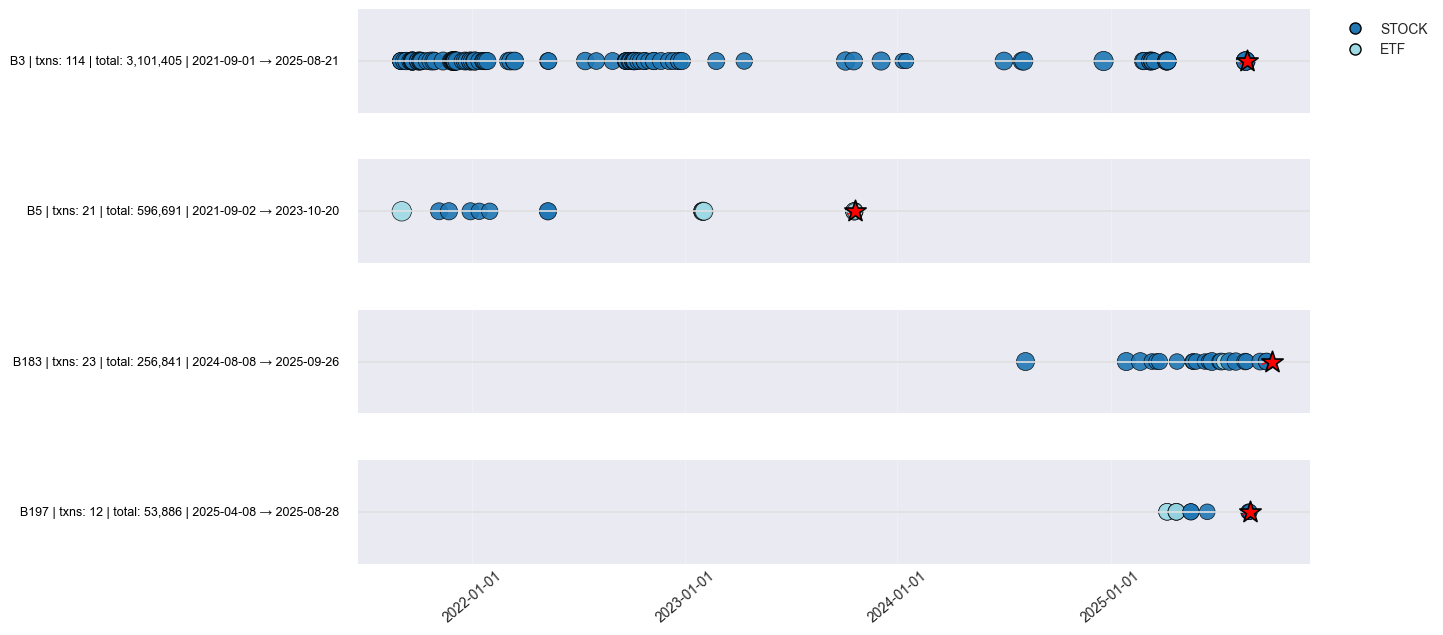

In [125]:
def plot_timeline_with_similars(df,
                                target_client,
                                n_similar=3,
                                similar_clients_list=None,
                                show_similar=True,
                                figsize_per_row=(14, 1.8)):
    """
    Improved version:
    - Text moved outside the plot area to prevent overlaps
    - Automatic left margin for labels
    - Slight vertical spacing between subplots
    """
    df = df.copy()
    df["Date"] = pd.to_datetime(df["Date"])

    # --- get similar customers ---
    if similar_clients_list is None and show_similar:
        try:
            similars_df = find_similar_customers(target_client, top_n=n_similar)
            similar_clients_list = similars_df["Client"].head(n_similar).tolist()
        except Exception:
            similar_clients_list = []
    rows = [target_client] + (similar_clients_list or [])
    if not rows:
        print("No clients to plot.")
        return

    # --- subset data ---
    plotted_df = df[df["Client"].isin(rows)]
    if plotted_df.empty:
        print("No transactions found for selected clients.")
        return

    unique_types = plotted_df["ProductType"].dropna().unique()
    cmap = plt.cm.get_cmap("tab20", len(unique_types))
    color_map = {pt: cmap(i) for i, pt in enumerate(unique_types)}

    # --- dynamic x limits ---
    min_date, max_date = plotted_df["Date"].min(), plotted_df["Date"].max()
    pad = pd.Timedelta(days=max(7, (max_date - min_date).days * 0.05))
    x_min, x_max = min_date - pad, max_date + pad

    n_rows = len(rows)
    fig, axes = plt.subplots(
        n_rows, 1, figsize=(figsize_per_row[0], figsize_per_row[1] * n_rows),
        sharex=True, gridspec_kw={'left': 0.22, 'hspace': 0.45}
    )
    if n_rows == 1:
        axes = [axes]

    # --- plotting loop ---
    for ax, client in zip(axes, rows):
        cdata = df[df["Client"] == client].sort_values("Date")
        if cdata.empty:
            ax.text(0.5, 0.5, f"{client} — No transactions", ha="center", va="center")
            continue

        sizes = (np.log1p(cdata["Amount"].abs()) * 14) + 20
        colors = [color_map.get(pt, "gray") for pt in cdata["ProductType"]]
        y_level = 0.5

        # baseline + points
        ax.hlines(y=y_level, xmin=x_min, xmax=x_max, color="#e0e0e0", lw=1.2)
        ax.scatter(cdata["Date"], [y_level]*len(cdata),
                   s=sizes, c=colors, edgecolors="black", lw=0.5, alpha=0.9)

        # summary text OUTSIDE plot (to left margin)
        total_amt = cdata["Amount"].sum()
        label = (f"{client} | txns: {len(cdata)} | "
                 f"total: {total_amt:,.0f} | "
                 f"{cdata['Date'].min().date()} → {cdata['Date'].max().date()}")
        ax.text(-0.02, y_level, label, transform=ax.transAxes,
                ha="right", va="center", fontsize=9, color="black")

        # predicted next purchase marker (if available)
        try:
            if "timing_predictions" in globals():
                pred_row = timing_predictions[timing_predictions["Client"] == client]
                if not pred_row.empty:
                    pred_date = pd.to_datetime(pred_row.iloc[0]["Predicted_Next_Purchase_Date"])
                    last_real = cdata["Date"].max()
                    ax.scatter(pred_date, y_level, marker="*", s=260, c="red",
                               edgecolors="black", lw=1.2, zorder=5)
                    ax.annotate("", xy=(pred_date, y_level), xytext=(last_real, y_level),
                                arrowprops=dict(arrowstyle="->", color="red", lw=1.1))
        except Exception:
            pass

        ax.set_yticks([])
        ax.set_ylim(0, 1)
        ax.grid(axis="x", alpha=0.25)
        ax.set_xlim(x_min, x_max)

    # bottom x-axis formatting
    locator = AutoDateLocator(minticks=4, maxticks=8)
    axes[-1].xaxis.set_major_locator(locator)
    axes[-1].xaxis.set_major_formatter(DateFormatter("%Y-%m-%d"))
    plt.xticks(rotation=40)

    # legend on top-right outside
    legend_elems = [
        mlines.Line2D([], [], marker="o", linestyle="",
                      markerfacecolor=color_map[pt], markeredgecolor="black",
                      markersize=8, label=pt)
        for pt in unique_types
    ]
    axes[0].legend(handles=legend_elems, bbox_to_anchor=(1.02, 1),
                   loc="upper left", frameon=False)

    plt.show()


# Example call
plot_timeline_with_similars(df, target_client="B3", n_similar=3)

In [126]:
# Final Summary Dashboard
print("\n" + "="*70)
print(" ANALYSIS SUMMARY")
print("="*70)

print(f"\n Dataset: {len(df)} transactions | {df['Client'].nunique()} clients")
print(f" Customer Clusters: {optimal_k} segments")
for cluster_id, name in cluster_names.items():
    count = len(client_features[client_features['Cluster'] == cluster_id])
    print(f"   - {name}: {count} customers")

print(f"\n Product Type Transitions: {len(transitions_df)} identified")
print(f" Association Rules: {len(rules) if len(rules) > 0 else 0} rules")
print(f"\n Amount Prediction Model: R² = {r2:.4f}, MAE = ${mae:,.2f}")
print(f" Timing Predictions: {len(timing_predictions)} clients")
print(f" Recommendations Generated: {len(recommendations_df)} clients")

print("\n" + "="*70)
print(" All enhancements complete! Ready for analysis.")
print("="*70)


 ANALYSIS SUMMARY

 Dataset: 3171 transactions | 190 clients
 Customer Clusters: 4 segments
   - Passive Long-Term Investor: 48 customers
   - Regular Retail Investor: 103 customers
   - Ultra High-Net-Worth: 1 customers
   - New/Single-Transaction: 38 customers

 Product Type Transitions: 2281 identified
 Association Rules: 115 rules

 Amount Prediction Model: R² = 0.8891, MAE = $9,206.06
 Timing Predictions: 190 clients
 Recommendations Generated: 190 clients

 All enhancements complete! Ready for analysis.
